In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/superstore.csv', encoding="cp1252")

print ("HEAD OF DATA\n")
df.head(5)

HEAD OF DATA



,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


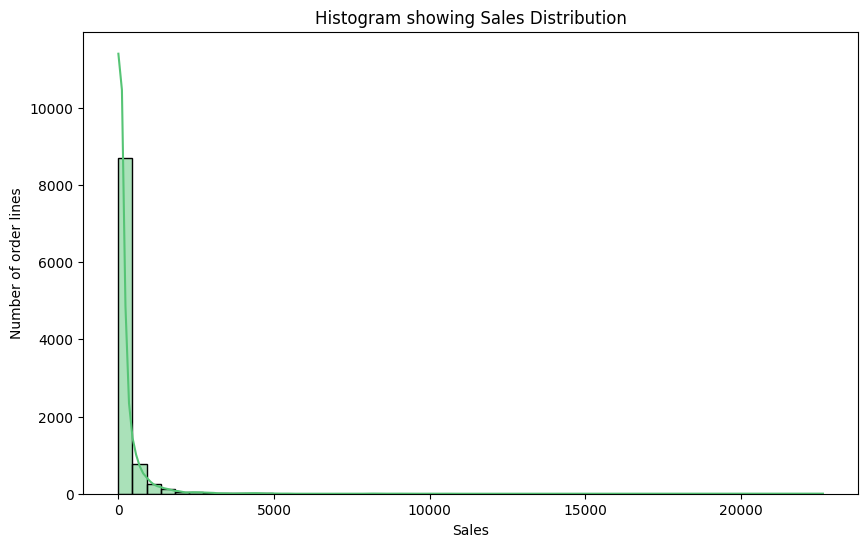

Skewness value: 12.97275234181623
Mean value: 229.85800083049833
Median value: 54.489999999999995


In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Sales'], bins=50, kde=True, color="#56c475")
plt.title("Histogram showing Sales Distribution")
plt.xlabel('Sales')
plt.ylabel('Number of order lines')
plt.show()


skew_value= df['Sales'].skew()
print("Skewness value:", skew_value)
mean_value=df['Sales'].mean()
median_value=df['Sales'].median()
print("Mean value:", mean_value)
print("Median value:", median_value)

The skewness value shows that the data is heavily right-skewed. More of the data points are piled up on the lower value side.

The mean value is 229.85 and the median value is 54. They are not the same which shows that the data is not normally distributed and assymmetric.

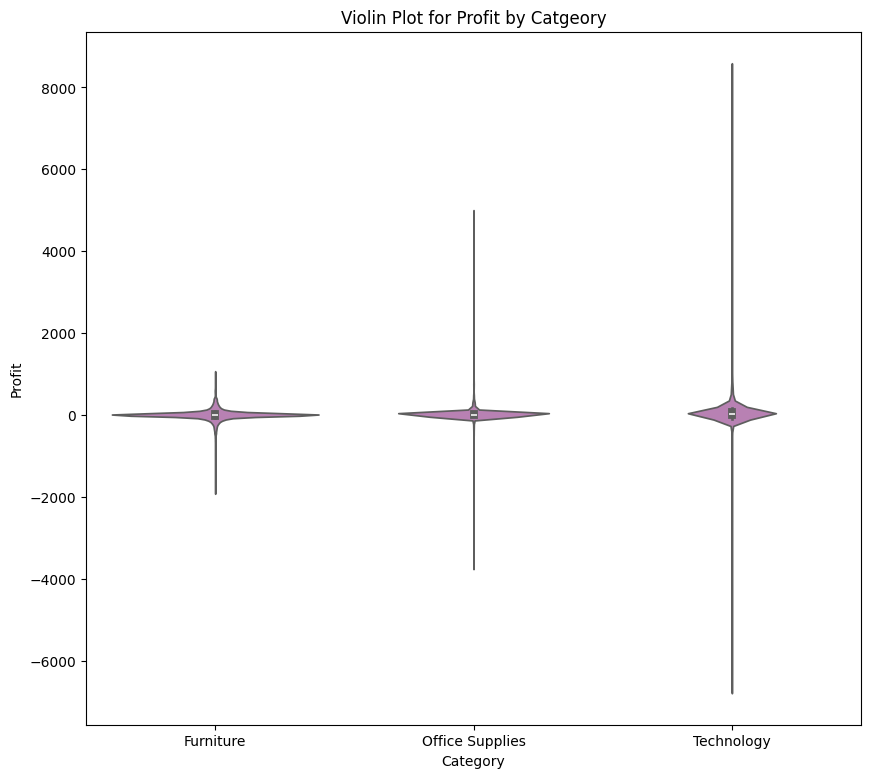

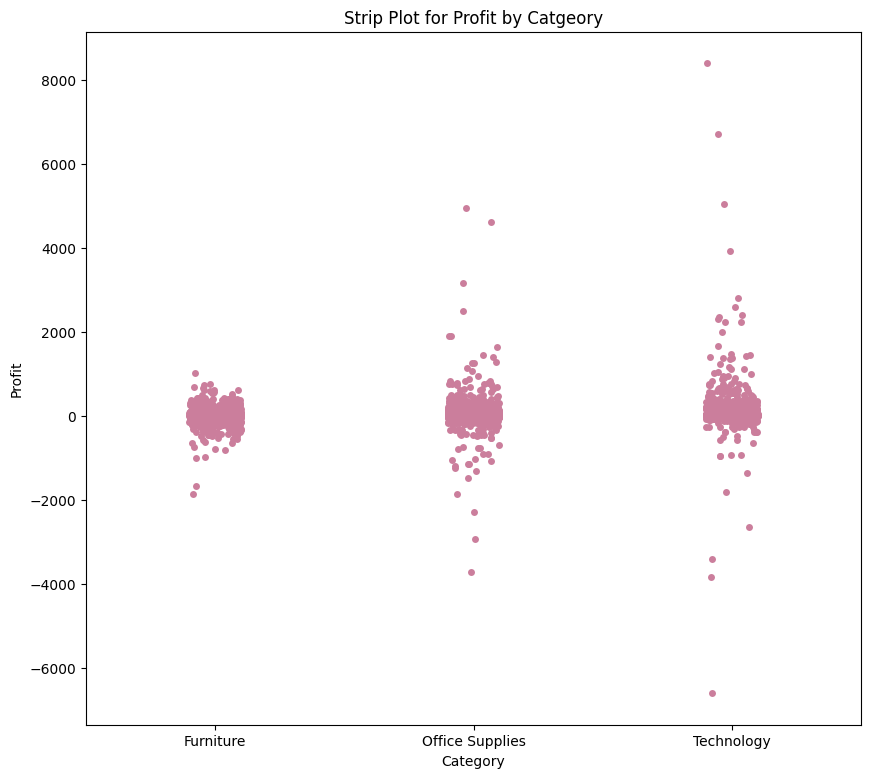

In [ ]:

plt.figure(figsize=(10,9))
plt.title("Violin Plot for Profit by Catgeory")
sns.violinplot(data=df, x='Category', y='Profit', color="#c178bb")
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()

plt.figure(figsize=(10,9))
plt.title("Strip Plot for Profit by Catgeory")
sns.stripplot(data=df, x='Category', y='Profit', jitter=True, color="#cb7e9c")
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()

The violin plot best shows the bimodal or unusual spread-out profit distribution because it shows the two distinct peaks. It shows the fully estimated density per category. On the other hand, the strip plot gives inidviduals points which doesn't explicitly shows collective trend.

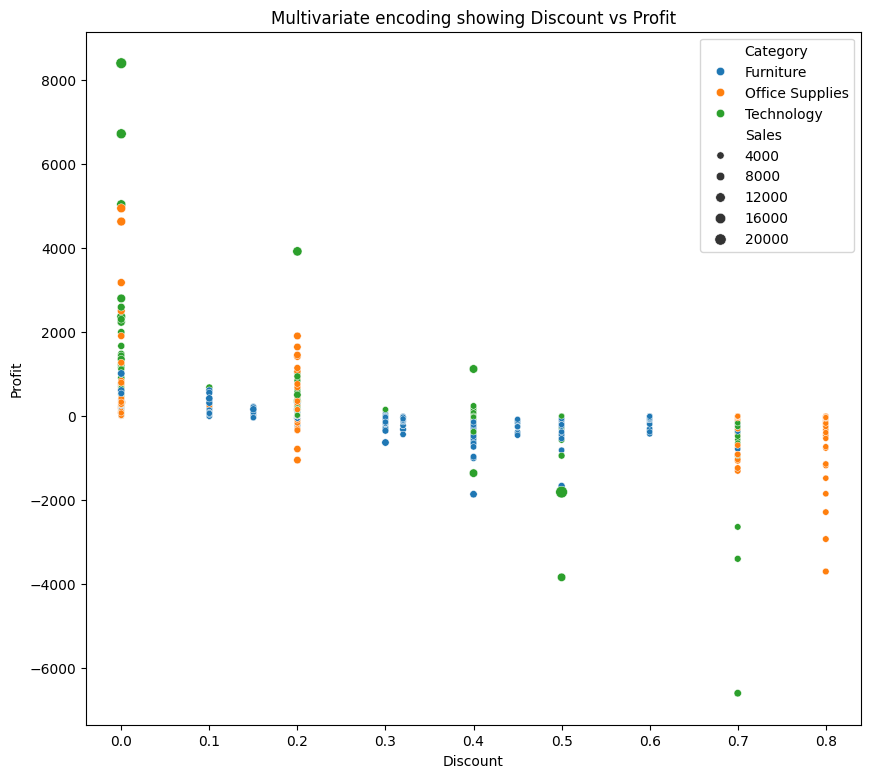

In [ ]:
plt.figure(figsize=(10, 9))
plt.title("Multivariate encoding showing Discount vs Profit")
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', size='Sales')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()

As discount increases, Office Supplies generally show lower profits, with many observations becoming negative. At higher discounts, their sales are also generally smaller compared with some Technology observations.

               Row ID  Postal Code     Sales  Quantity  Discount    Profit
Row ID       1.000000     0.009671 -0.001359 -0.004016  0.013480  0.012497
Postal Code  0.009671     1.000000 -0.023854  0.012761  0.058443 -0.029961
Sales       -0.001359    -0.023854  1.000000  0.200795 -0.028190  0.479064
Quantity    -0.004016     0.012761  0.200795  1.000000  0.008623  0.066253
Discount     0.013480     0.058443 -0.028190  0.008623  1.000000 -0.219487
Profit       0.012497    -0.029961  0.479064  0.066253 -0.219487  1.000000
               Row ID  Postal Code     Sales  Quantity  Discount    Profit
Row ID       1.000000     0.011466 -0.001310 -0.002416  0.012655 -0.010545
Postal Code  0.011466     1.000000 -0.002059  0.013952  0.052793 -0.005451
Sales       -0.001310    -0.002059  1.000000  0.327426 -0.056969  0.518407
Quantity    -0.002416     0.013952  0.327426  1.000000 -0.000878  0.234491
Discount     0.012655     0.052793 -0.056969 -0.000878  1.000000 -0.543350
Profit      -0.010545    

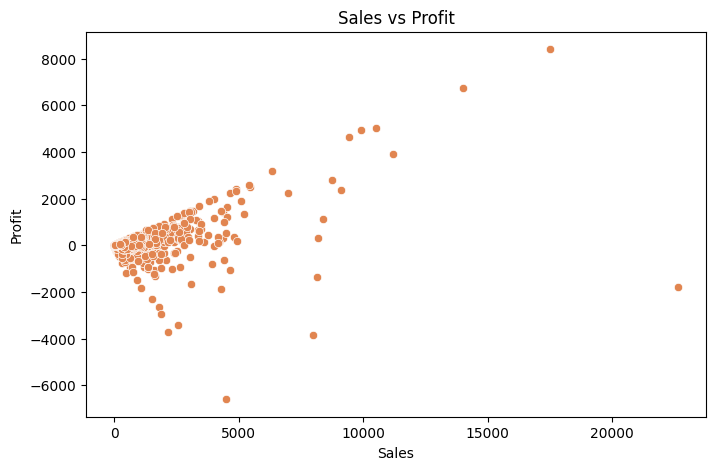

In [ ]:
numeric_df = df.select_dtypes(include='number')
print(numeric_df.corr(method='pearson'))

print(numeric_df.corr(method='spearman'))


plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x='Sales', y='Profit', color='#e18550')

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.show()

There is no straightline in the scatter plot because there are many outliers which show that the they are not exactly linear in relationship. there is deviation from a straightline relationship. this tells that correlation is not causation two variables can move together because on causes other, both are caused by a third variable or by pure coincidence.

Category    Furniture  Office Supplies  Technology           All
Region                                                          
Central   163797.1638       167026.415  170416.312  5.012399e+05
East      208291.2040       205516.055  264973.981  6.787812e+05
South     117298.6840       125651.313  148771.908  3.917219e+05
West      252612.7435       220853.249  251991.832  7.254578e+05
All       741999.7953       719047.032  836154.033  2.297201e+06


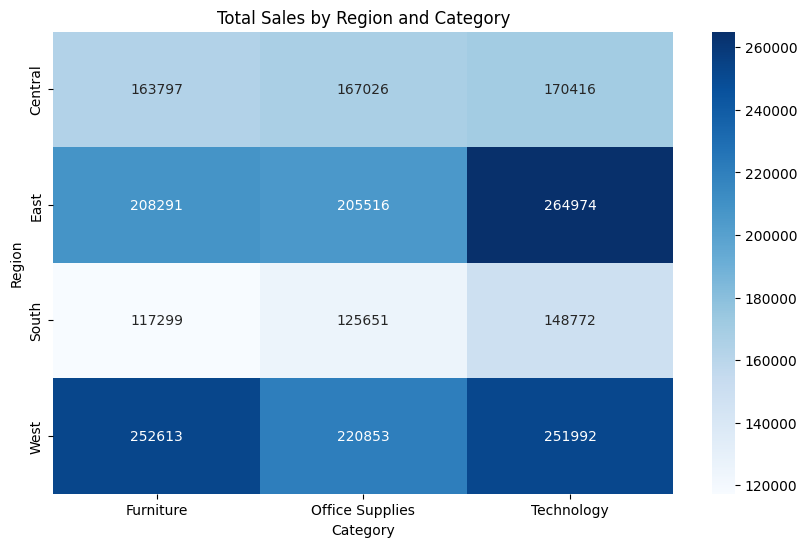

In [ ]:
table= pd.pivot_table(df, values="Sales", index='Region', columns='Category', aggfunc='sum', margins=True)
print(table)

heatmap_table = table.drop(index="All", columns="All")

plt.figure(figsize=(10, 6))

sns.heatmap(heatmap_table, annot=True,fmt='.0f',cmap='Blues')

plt.title('Total Sales by Region and Category')
plt.xlabel('Category')
plt.ylabel('Region')

plt.show()


/tmp/ipykernel_2891/942873416.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df['Sales'].resample('M').sum()


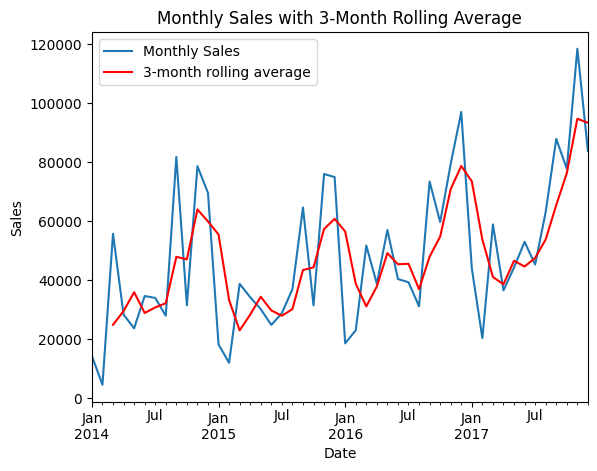

In [48]:
df['order_date'] = pd.to_datetime(df['Order Date'])

df = df.set_index('order_date')

monthly = df['Sales'].resample('M').sum()

monthly_totals_rolling = monthly.rolling(window=3).mean()

monthly.plot(label='Monthly Sales')
monthly_totals_rolling.plot(label='3-month rolling average', color="red")

plt.legend()
plt.title('Monthly Sales with 3-Month Rolling Average')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

The 3-month rolling average smooths out short-term fluctuations and random noise in monthly sales, making the overall sales trend easier to see. It reveals whether sales are generally increasing or decreasing over time without being affected as much by unusually high or low sales in individual months.

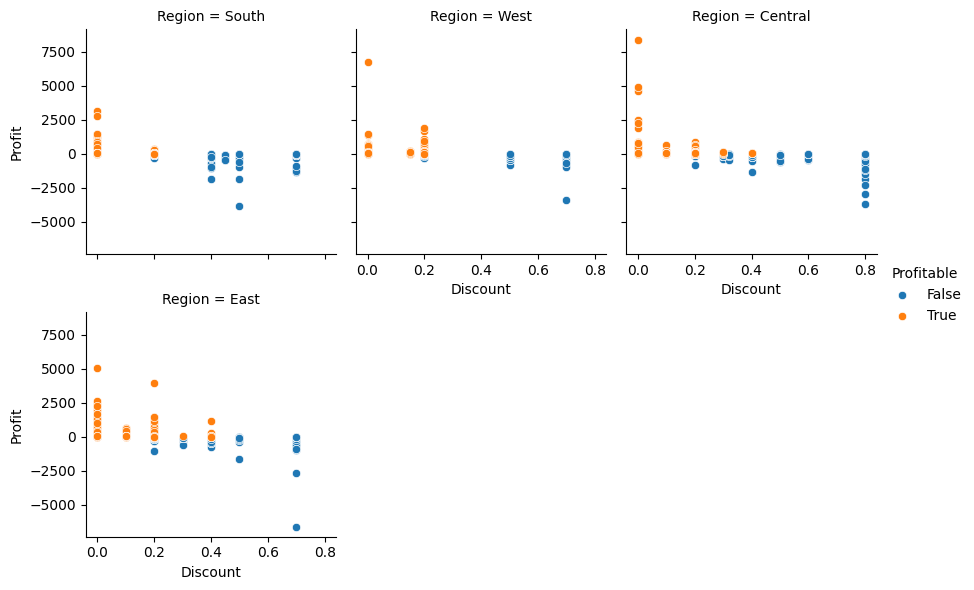

In [40]:
# Create a profitable/non-profitable variable
df['Profitable'] = df['Profit'] > 0

# Facet by Region and color by profitability
g = sns.FacetGrid(
    df,
    col='Region',
    hue='Profitable',
    col_wrap=3
)

g.map(
    sns.scatterplot,
    'Discount',
    'Profit'
)

g.add_legend()

plt.show()

In the central region the proft-discount relationship visibly varies. There are noticeable peaks and dips which shows that the relationship varies a lot.


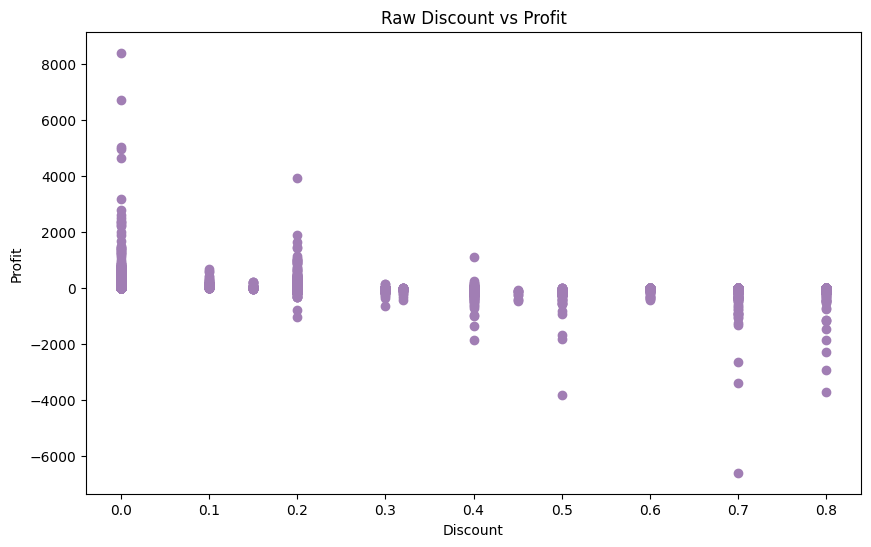

In [46]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['Discount'],
    df['Profit']
    , color="#a17eb4"
)

plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Raw Discount vs Profit')

plt.show()


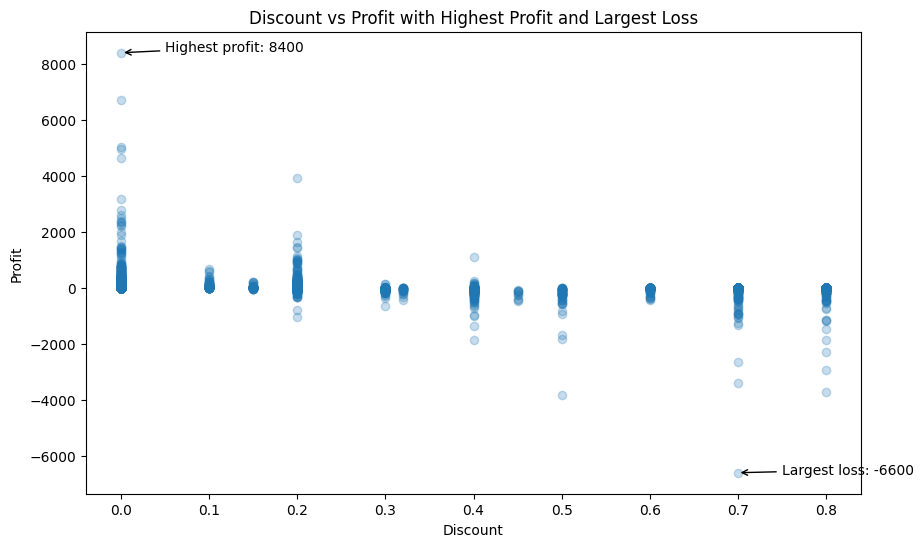

In [49]:

df = df.loc[:, ~df.columns.duplicated()].copy()

df['Profit'] = pd.to_numeric(df['Profit'], errors='coerce')
df['Discount'] = pd.to_numeric(df['Discount'], errors='coerce')


plot_df = df[['Discount', 'Profit']].dropna().reset_index(drop=True)

best_idx = plot_df['Profit'].argmax()
worst_idx = plot_df['Profit'].argmin()

best_discount = plot_df.loc[best_idx, 'Discount']
best_profit = plot_df.loc[best_idx, 'Profit']

worst_discount = plot_df.loc[worst_idx, 'Discount']
worst_profit = plot_df.loc[worst_idx, 'Profit']

# Plot
plt.figure(figsize=(10, 6))

plt.scatter(
    plot_df['Discount'],
    plot_df['Profit'],
    alpha=0.25
)

# Annotate highest profit
plt.annotate(
    f'Highest profit: {best_profit:.0f}',
    xy=(best_discount, best_profit),
    xytext=(best_discount + 0.05, best_profit + 50),
    arrowprops=dict(arrowstyle='->')
)

# Annotate largest loss
plt.annotate(
    f'Largest loss: {worst_profit:.0f}',
    xy=(worst_discount, worst_profit),
    xytext=(worst_discount + 0.05, worst_profit - 50),
    arrowprops=dict(arrowstyle='->')
)

plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Discount vs Profit with Highest Profit and Largest Loss')
plt.show()

Transparency (alpha=0.25) is used because many points overlap,making dense areas easier to see while still showing individual observations.